In [ ]:
import os
import random
import shutil

# Definir los directorios de origen y destino
src_folder = "spectrums"
dst_folder = "spectrums training 50k"

# Crear la carpeta de destino si no existe
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# Listar todos los archivos .fits en el directorio de origen
fits_files = [f for f in os.listdir(src_folder) if f.lower().endswith(".fits")]

# Seleccionar 50000 archivos aleatorios
selected_files = random.sample(fits_files, 50000)

# Copiar cada archivo seleccionado a la carpeta de destino
for file in selected_files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    shutil.copy(src_path, dst_path)
    print(f"Copiado: {file}")

print("Copia completada.")

Procesado spec-5322-56003-0921.fits: redshift = 0.4838162958621979
Procesado spec-5323-55957-0062.fits: redshift = 0.7797300219535828
Procesado spec-5323-55957-0219.fits: redshift = 0.5606951713562012
Procesado spec-5323-55957-0264.fits: redshift = 0.6238718032836914
Procesado spec-5323-55957-0318.fits: redshift = 1.4313517808914185
Procesado spec-5323-55957-0325.fits: redshift = 0.4415435194969177
Procesado spec-5323-55957-0327.fits: redshift = 0.536208987236023
Procesado spec-5323-55957-0400.fits: redshift = 0.7552723288536072
Procesado spec-5323-55957-0432.fits: redshift = 0.4212093949317932
Procesado spec-5323-55957-0450.fits: redshift = 0.19574008882045746
Procesado spec-5323-55957-0574.fits: redshift = 0.3484915792942047
Procesado spec-5323-55957-0601.fits: redshift = 0.47951507568359375
Procesado spec-5323-55957-0796.fits: redshift = 1.2339098453521729
Procesado spec-5323-55957-0819.fits: redshift = 0.492584764957428
Procesado spec-5323-55957-0871.fits: redshift = 0.599028229713

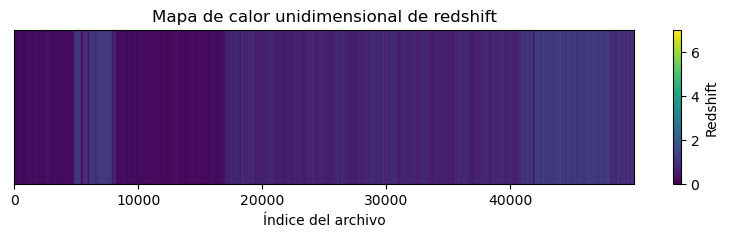

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Lista para almacenar los valores de redshift
redshift_values = []

# Recorrer todos los archivos .fits en la carpeta
for filename in os.listdir(dst_folder):
    if filename.lower().endswith('.fits'):
        file_path = os.path.join(dst_folder, filename)
        try:
            with fits.open(file_path) as hdul:
                # Se espera que el archivo tenga al menos tres extensiones
                if len(hdul) > 2:
                    # Extraer redshift (se asume que está en la extensión 2, campo "Z")
                    redshift = hdul[2].data["Z"][0]
                    redshift_values.append(redshift)
                    # print(f"Procesado {filename}: redshift = {redshift}")
                else:
                    print(f"El archivo {filename} no tiene suficientes extensiones.")
        except Exception as e:
            print(f"Error procesando {filename}: {e}")

# Convertir la lista a un arreglo de numpy
redshift_array = np.array(redshift_values)

# Verificar que se hayan obtenido valores de redshift
if redshift_array.size == 0:
    print("No se encontraron valores de redshift.")
else:
    # Crear un arreglo 2D con una sola fila para el mapa de calor
    heatmap_data = redshift_array.reshape(1, -1)

    plt.figure(figsize=(10, 2))
    # Usamos imshow para representar el arreglo como un mapa de calor
    plt.imshow(heatmap_data, aspect='auto', cmap='viridis')
    plt.colorbar(label='Redshift')
    plt.title('Mapa de calor unidimensional de redshift')
    plt.xlabel('Índice del archivo')
    plt.yticks([])  # Eliminamos las marcas del eje y
    plt.show()

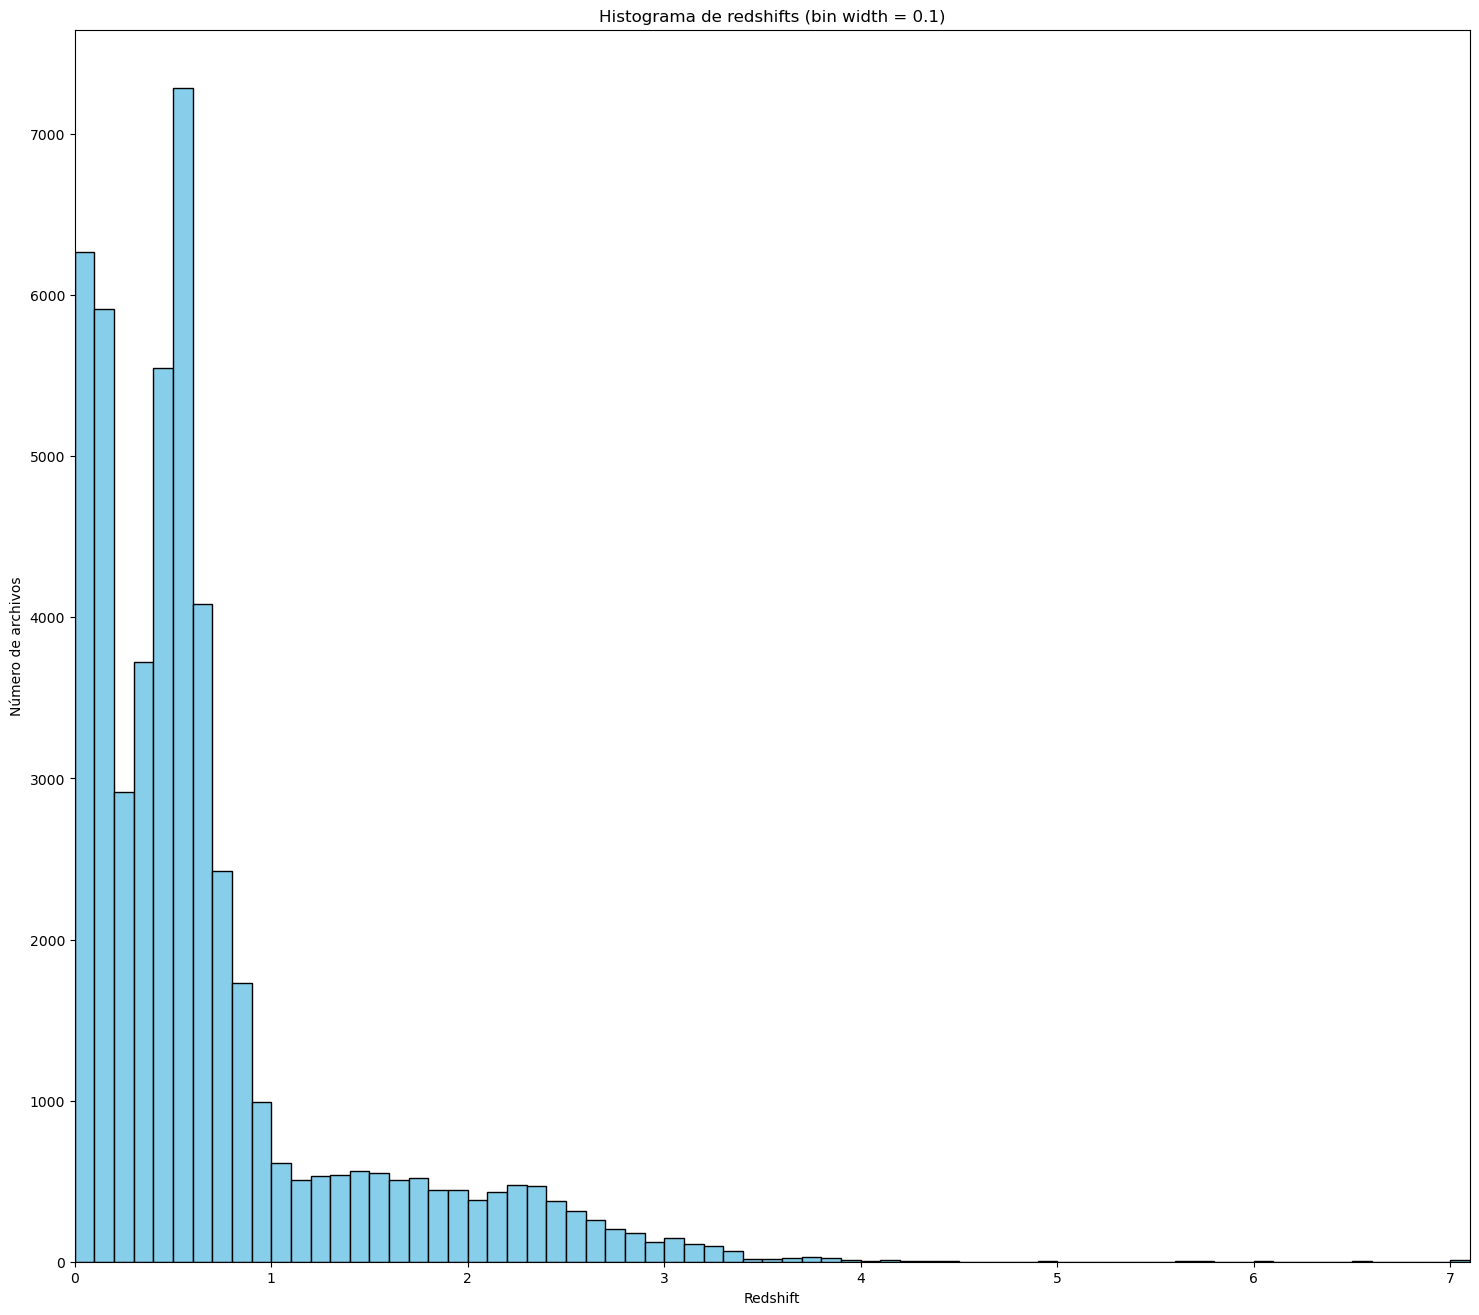

In [5]:
# Definir los bins con intervalos de 0.1
bins = np.arange(0, redshift_array.max() + 0.1, 0.1)

plt.figure(figsize=(18,16))
plt.hist(redshift_array, bins=bins, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de archivos")
plt.title("Histograma de redshifts (bin width = 0.1)")
plt.xlim(0, 7.1)
plt.show()
